In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

In [70]:
df = pd.read_excel("Telco_Customer_Churn_Full_33.xlsx")
df.head()

,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason,ID,Population
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data,21,68701
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer,54,55668
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer,56,47534
3,4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services,100,27778
4,4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,1,67,2793,Price,Extra data charges,114,26265


In [71]:
df.shape

(7043, 54)

In [72]:
df.columns

Index(['Customer ID', 'Count', 'Gender', 'Age', 'Under 30', 'Senior Citizen',
       'Married', 'Dependents', 'Number of Dependents', 'Country', 'State',
       'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason',
       'ID', 'Population']

In [73]:
df.dtypes

,0
Customer ID,object
Count,int64
Gender,object
Age,int64
Under 30,object
Senior Citizen,object
Married,object
Dependents,object
Number of Dependents,int64
Country,object


In [74]:
df.isna().sum().sort_values(ascending=False)

,0
Churn Category,5174
Churn Reason,5174
Offer,3877
Internet Type,1526
Gender,0
Customer ID,0
Senior Citizen,0
Married,0
Number of Dependents,0
Dependents,0


In [75]:
telco = df[['Customer ID',
            'Gender',
            'Age',
            'Married',
            'Number of Dependents',
            'Number of Referrals',
            'Tenure in Months',
            'Offer',
            'Phone Service',
            'Multiple Lines',
            'Internet Service',
            'Internet Type',
            'Online Security',
            'Online Backup',
            'Device Protection Plan',
            'Premium Tech Support',
            'Streaming TV',
            'Streaming Movies',
            'Streaming Music',
            'Unlimited Data',
            'Contract',
            'Paperless Billing',
            'Payment Method',
            'Monthly Charge',
            'Total Charges',
            'CLTV',
            'Satisfaction Score',
            'Customer Status',
            'Churn Label',
            'Churn Value',
            'Churn Category',
            'Churn Reason',
            'City',
            'Zip Code',
            'Population']].copy()

telco.head()

,Customer ID,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,CLTV,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Category,Churn Reason,City,Zip Code,Population
0,8779-QRDMV,Male,78,No,0,0,1,NaN,No,No,Yes,DSL,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,5433,3,Churned,Yes,1,Competitor,Competitor offered more data,Los Angeles,90022,68701
1,7495-OOKFY,Female,74,Yes,1,1,8,Offer E,Yes,Yes,Yes,Fiber Optic,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,5302,3,Churned,Yes,1,Competitor,Competitor made better offer,Los Angeles,90063,55668
2,1658-BYGOY,Male,71,No,3,0,18,Offer D,Yes,Yes,Yes,Fiber Optic,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,3179,2,Churned,Yes,1,Competitor,Competitor made better offer,Los Angeles,90065,47534
3,4598-XLKNJ,Female,78,Yes,1,1,25,Offer C,Yes,No,Yes,Fiber Optic,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,5337,2,Churned,Yes,1,Dissatisfaction,Limited range of services,Inglewood,90303,27778
4,4846-WHAFZ,Female,80,Yes,1,1,37,Offer C,Yes,Yes,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,2793,2,Churned,Yes,1,Price,Extra data charges,Whittier,90602,26265


In [76]:
telco.columns = telco.columns.str.strip().str.lower().str.replace(' ', '_')
telco.head()

,customer_id,gender,age,married,number_of_dependents,number_of_referrals,tenure_in_months,offer,phone_service,multiple_lines,internet_service,internet_type,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,total_charges,cltv,satisfaction_score,customer_status,churn_label,churn_value,churn_category,churn_reason,city,zip_code,population
0,8779-QRDMV,Male,78,No,0,0,1,NaN,No,No,Yes,DSL,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,5433,3,Churned,Yes,1,Competitor,Competitor offered more data,Los Angeles,90022,68701
1,7495-OOKFY,Female,74,Yes,1,1,8,Offer E,Yes,Yes,Yes,Fiber Optic,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,5302,3,Churned,Yes,1,Competitor,Competitor made better offer,Los Angeles,90063,55668
2,1658-BYGOY,Male,71,No,3,0,18,Offer D,Yes,Yes,Yes,Fiber Optic,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,3179,2,Churned,Yes,1,Competitor,Competitor made better offer,Los Angeles,90065,47534
3,4598-XLKNJ,Female,78,Yes,1,1,25,Offer C,Yes,No,Yes,Fiber Optic,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,5337,2,Churned,Yes,1,Dissatisfaction,Limited range of services,Inglewood,90303,27778
4,4846-WHAFZ,Female,80,Yes,1,1,37,Offer C,Yes,Yes,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,2793,2,Churned,Yes,1,Price,Extra data charges,Whittier,90602,26265


In [77]:
telco['total_charges'] = telco['total_charges'].replace(' ', np.nan)
telco['total_charges'] = pd.to_numeric(telco['total_charges'], errors='coerce')

telco['age'] = pd.to_numeric(telco['age'], errors='coerce')
telco['number_of_dependents'] = pd.to_numeric(telco['number_of_dependents'], errors='coerce')
telco['number_of_referrals'] = pd.to_numeric(telco['number_of_referrals'], errors='coerce')
telco['tenure_in_months'] = pd.to_numeric(telco['tenure_in_months'], errors='coerce')
telco['monthly_charge'] = pd.to_numeric(telco['monthly_charge'], errors='coerce')
telco['cltv'] = pd.to_numeric(telco['cltv'], errors='coerce')
telco['satisfaction_score'] = pd.to_numeric(telco['satisfaction_score'], errors='coerce')
telco['population'] = pd.to_numeric(telco['population'], errors='coerce')

In [78]:
(telco['tenure_in_months'] == 0).sum()

np.int64(0)

In [79]:
((telco['tenure_in_months'] == 0) & (telco['total_charges'].isna())).sum()

np.int64(0)

In [80]:
telco.loc[(telco['tenure_in_months'] == 0) & (telco['total_charges'].isna()), 'total_charges'] = 0

In [81]:
telco.isna().sum().sort_values(ascending=False)

,0
churn_category,5174
churn_reason,5174
offer,3877
internet_type,1526
age,0
customer_id,0
gender,0
tenure_in_months,0
phone_service,0
number_of_referrals,0


In [82]:
yes_no_cols = ['married',
               'phone_service',
               'multiple_lines',
               'internet_service',
               'online_security',
               'online_backup',
               'device_protection_plan',
               'premium_tech_support',
               'streaming_tv',
               'streaming_movies',
               'streaming_music',
               'unlimited_data',
               'paperless_billing',
               'churn_label']

for col in yes_no_cols:
    telco[col] = telco[col].replace({'Yes': 1,
                                     'No': 0,
                                     'No internet service': 0,
                                     'No phone service': 0})

/tmp/ipykernel_646/141696119.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telco[col] = telco[col].replace({'Yes': 1,


In [83]:
for col in yes_no_cols:
    print(col, telco[col].dropna().unique())

married [0 1]
phone_service [0 1]
multiple_lines [0 1]
internet_service [1 0]
online_security [0 1]
online_backup [0 1]
device_protection_plan [1 0]
premium_tech_support [0 1]
streaming_tv [0 1]
streaming_movies [1 0]
streaming_music [0 1]
unlimited_data [0 1]
paperless_billing [1 0]
churn_label [1 0]


In [84]:
telco['churn_value'] = pd.to_numeric(telco['churn_value'], errors='coerce')
telco['churn_value'].mean()

np.float64(0.2653698707936959)

In [85]:
churn_rate = telco['churn_value'].mean()
churn_rate

np.float64(0.2653698707936959)

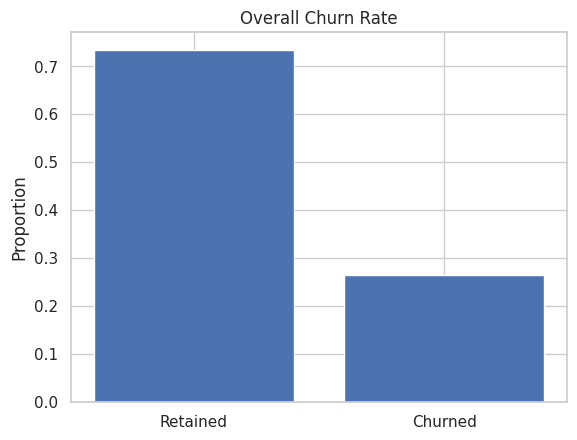

In [86]:
plt.bar(['Retained', 'Churned'], [1 - churn_rate, churn_rate])
plt.ylabel('Proportion')
plt.title('Overall Churn Rate')
plt.show()

In [87]:
contract_churn = telco.groupby('contract')['churn_value'].mean()
contract_churn

,churn_value
contract,
Month-to-Month,0.458449
One Year,0.107097
Two Year,0.025491


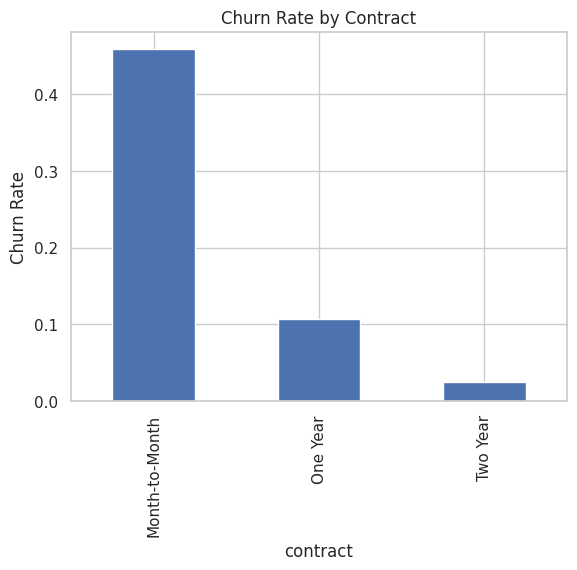

In [88]:
contract_churn.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Contract')
plt.show()

In [89]:
internet_churn = telco.groupby('internet_type')['churn_value'].mean()
internet_churn

,churn_value
internet_type,
Cable,0.256627
DSL,0.185835
Fiber Optic,0.407249


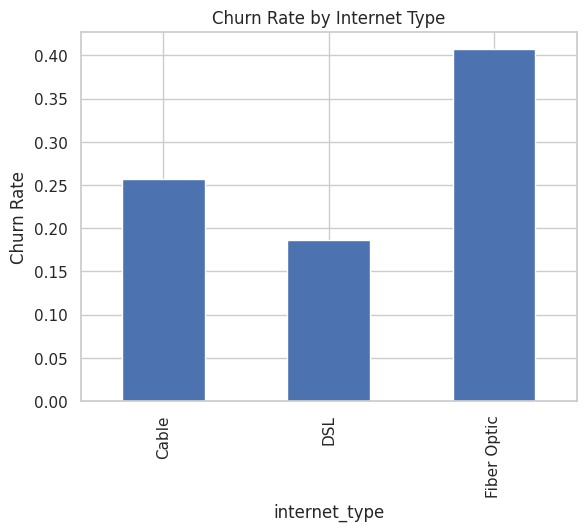

In [90]:
internet_churn.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Internet Type')
plt.show()

In [91]:
telco['tenure_band'] = pd.cut(telco['tenure_in_months'],
                              bins=[-1, 12, 36, 100],
                              labels=['New', 'Developing', 'Established'])

In [92]:
tenure_churn = telco.groupby('tenure_band')['churn_value'].mean()
tenure_churn

/tmp/ipykernel_646/3418106703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = telco.groupby('tenure_band')['churn_value'].mean()


,churn_value
tenure_band,
New,0.474382
Developing,0.255388
Established,0.119294


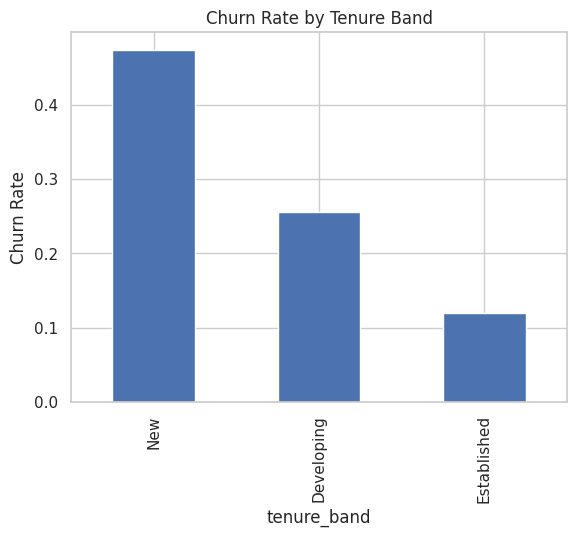

In [93]:
tenure_churn.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Tenure Band')
plt.show()

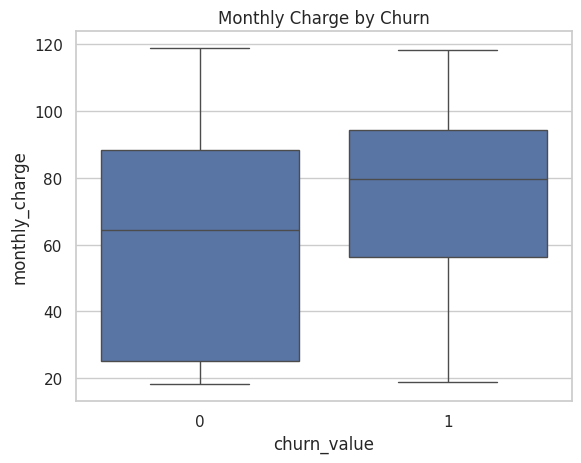

In [94]:
sns.boxplot(x='churn_value', y='monthly_charge', data=telco)
plt.title('Monthly Charge by Churn')
plt.show()

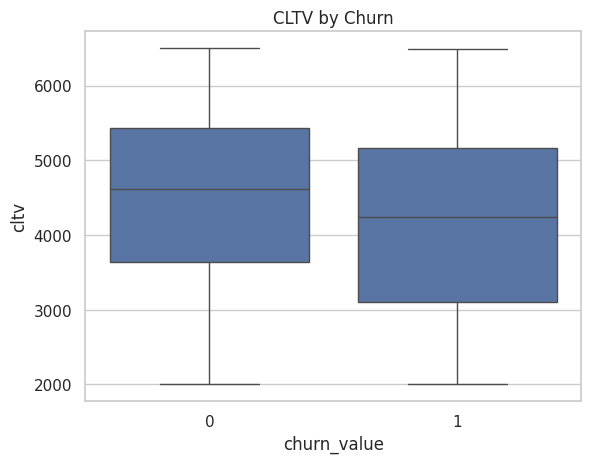

In [95]:
sns.boxplot(x='churn_value', y='cltv', data=telco)
plt.title('CLTV by Churn')
plt.show()

In [96]:
telco[telco['churn_value'] == 1]['churn_category'].value_counts()

,count
churn_category,
Competitor,841
Attitude,314
Dissatisfaction,303
Price,211
Other,200


In [97]:
telco[telco['churn_value'] == 1]['churn_reason'].value_counts().head(10)

,count
churn_reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


In [98]:
bundle_cols = ['online_security',
               'online_backup',
               'device_protection_plan',
               'premium_tech_support',
               'streaming_tv',
               'streaming_movies',
               'streaming_music',
               'unlimited_data']

telco['service_bundle_count'] = telco[bundle_cols].sum(axis=1)
telco['service_bundle_count'].describe()

,service_bundle_count
count,7043.000000
mean,3.064887
std,2.418315
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,8.000000


In [99]:
telco['tenure_segment'] = pd.cut(telco['tenure_in_months'],
                                 bins=[-1, 12, 36, 100],
                                 labels=['new', 'developing', 'established'])

In [100]:
engagement = telco[['number_of_referrals', 'service_bundle_count', 'tenure_in_months']].copy()

scaler = StandardScaler()
engagement_scaled = scaler.fit_transform(engagement)

telco['engagement_index'] = engagement_scaled.mean(axis=1)
telco['engagement_index'].describe()

,engagement_index
count,7.043000e+03
mean,-3.228364e-17
std,7.282944e-01
min,-1.065617e+00
25%,-6.113273e-01
50%,-1.107690e-01
75%,5.105497e-01
max,2.112303e+00


In [101]:
cluster_data = telco[['tenure_in_months',
                      'monthly_charge',
                      'cltv',
                      'satisfaction_score',
                      'number_of_referrals',
                      'service_bundle_count',
                      'engagement_index']].copy()

cluster_data = cluster_data.fillna(cluster_data.median())
cluster_data.head()

,tenure_in_months,monthly_charge,cltv,satisfaction_score,number_of_referrals,service_bundle_count,engagement_index
0,1,39.65,5433,3,0,2,-0.789923
1,8,80.65,5302,3,1,2,-0.583767
2,18,95.45,3179,2,0,4,-0.283317
3,25,98.50,5337,2,1,5,0.060686
4,37,76.50,2793,2,1,1,-0.327704


In [102]:
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

In [103]:
inertia = []
sil = []

for k in range(3, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=1)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(cluster_scaled, km.labels_))

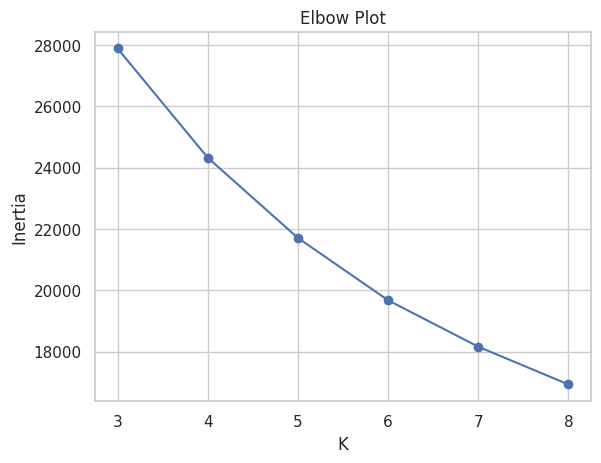

In [104]:
plt.plot(range(3, 9), inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Plot')
plt.show()

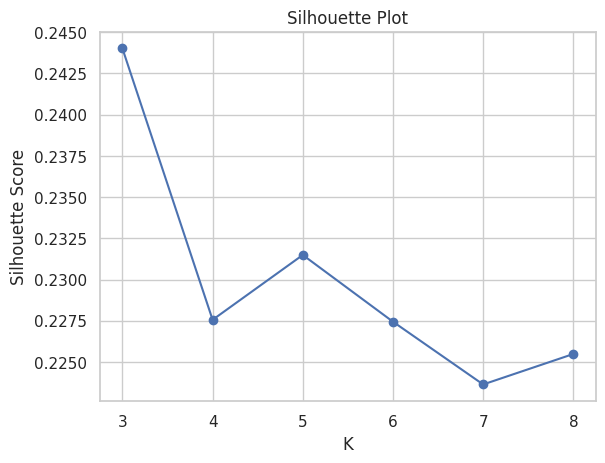

In [105]:
plt.plot(range(3, 9), sil, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Plot')
plt.show()

In [106]:
km = KMeans(n_clusters=4, n_init=20, random_state=1)
km.fit(cluster_scaled)
telco['cluster'] = km.labels_

In [107]:
profile = telco.groupby('cluster')[['churn_value',
                                    'monthly_charge',
                                    'tenure_in_months',
                                    'cltv',
                                    'service_bundle_count',
                                    'number_of_referrals',
                                    'engagement_index',
                                    'satisfaction_score']].mean()

profile

,churn_value,monthly_charge,tenure_in_months,cltv,service_bundle_count,number_of_referrals,engagement_index,satisfaction_score
cluster,,,,,,,,
0,0.672944,73.573013,13.396417,3813.464401,2.911346,0.449242,-0.446016,2.212678
1,0.158551,88.332215,54.195962,5024.640143,5.419240,0.924584,0.506671,3.386580
2,0.016436,72.808607,51.153114,4769.906574,4.198097,7.575260,1.035730,3.671280
3,0.058243,31.110538,23.957058,4301.019250,0.626357,1.211747,-0.532854,3.993090


In [108]:
telco.groupby('cluster')['contract'].agg(lambda x: x.mode()[0])

,contract
cluster,
0,Month-to-Month
1,Two Year
2,Two Year
3,Month-to-Month


In [109]:
telco['cluster'].value_counts().sort_index()

,count
cluster,
0,2177
1,1684
2,1156
3,2026


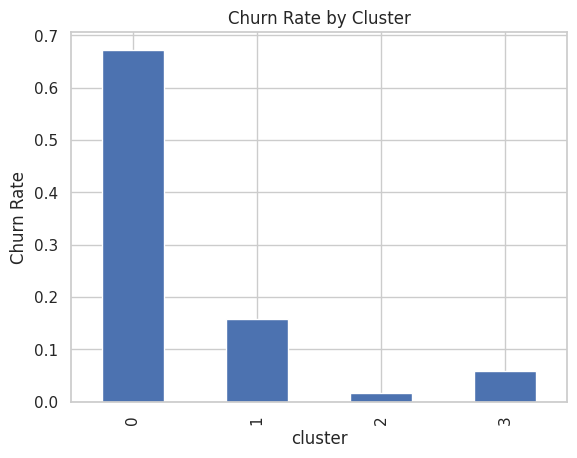

In [110]:
profile['churn_value'].plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Cluster')
plt.show()

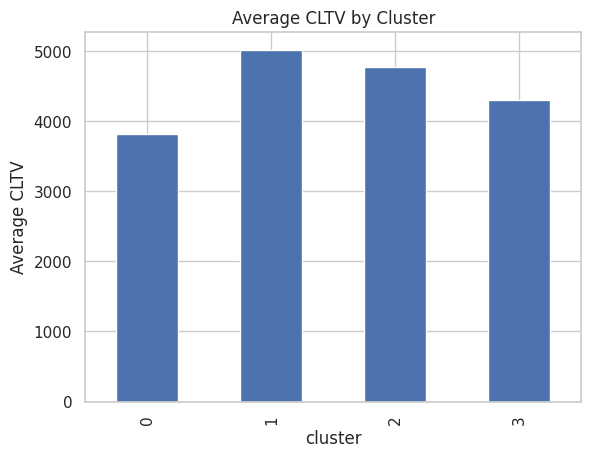

In [111]:
profile['cltv'].plot(kind='bar')
plt.ylabel('Average CLTV')
plt.title('Average CLTV by Cluster')
plt.show()

In [112]:
size = telco.groupby('cluster').size()
churn = telco.groupby('cluster')['churn_value'].mean()
cltv = telco.groupby('cluster')['cltv'].mean()

risk = pd.DataFrame({'size': size, 'churn_rate': churn, 'avg_cltv': cltv})
risk['weekly_revenue_at_risk'] = (risk['size'] / 13) * risk['churn_rate'] * risk['avg_cltv']
risk

,size,churn_rate,avg_cltv,weekly_revenue_at_risk
cluster,,,,
0,2177,0.672944,3813.464401,429748.103601
1,1684,0.158551,5024.640143,103198.378312
2,1156,0.016436,4769.906574,6971.401916
3,2026,0.058243,4301.019250,39040.020882


In [113]:
risk = risk.sort_values('weekly_revenue_at_risk', ascending=False)
risk

,size,churn_rate,avg_cltv,weekly_revenue_at_risk
cluster,,,,
0,2177,0.672944,3813.464401,429748.103601
1,1684,0.158551,5024.640143,103198.378312
3,2026,0.058243,4301.019250,39040.020882
2,1156,0.016436,4769.906574,6971.401916


In [127]:
cluster_name = {
    0: 'Early High-Risk Customers',
    1: 'High-Value Bundled Customers',
    2: 'Loyal Advocate Customers',
    3: 'Stable Low-Usage Customers'
}

telco['cluster_name'] = telco['cluster'].map(cluster_name)
profile['cluster_name'] = profile.index.map(cluster_name)
risk['cluster_name'] = risk.index.map(cluster_name)

telco[['cluster', 'cluster_name']].drop_duplicates().sort_values('cluster')

,cluster,cluster_name
1,0,Early High-Risk Customers
3,1,High-Value Bundled Customers
7,2,Loyal Advocate Customers
0,3,Stable Low-Usage Customers


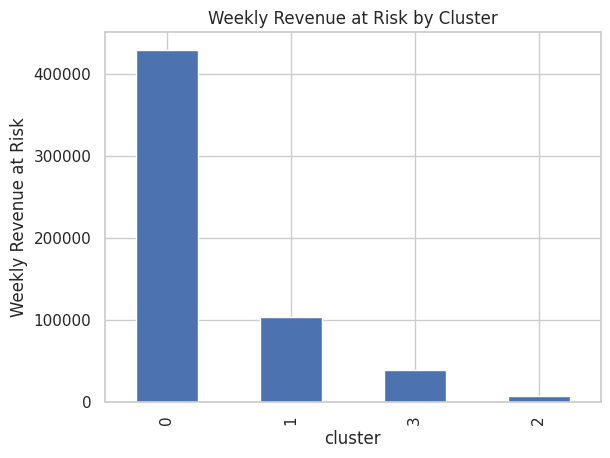

In [116]:
risk['weekly_revenue_at_risk'].plot(kind='bar')
plt.ylabel('Weekly Revenue at Risk')
plt.title('Weekly Revenue at Risk by Cluster')
plt.show()

In [117]:
pca = PCA()
pc = pca.fit_transform(cluster_scaled)

pca.explained_variance_ratio_

array([4.38876246e-01, 2.19693349e-01, 1.33214214e-01, 1.09609546e-01,
       6.91799533e-02, 2.94266915e-02, 7.50984092e-17])

In [118]:
np.cumsum(pca.explained_variance_ratio_)

array([0.43887625, 0.6585696 , 0.79178381, 0.90139336, 0.97057331,
       1.        , 1.        ])

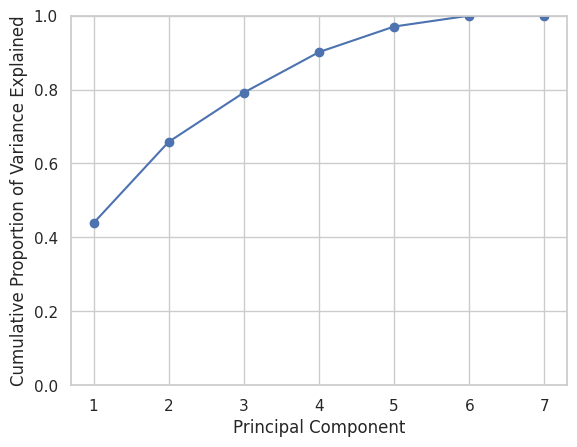

In [119]:
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_),
         marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.ylim(0, 1)
plt.show()

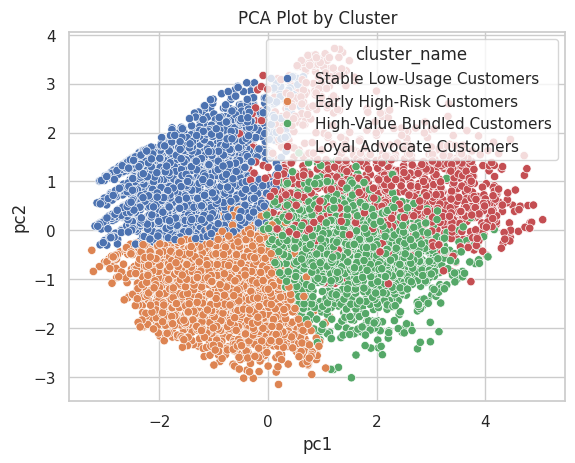

In [128]:
telco['pc1'] = pc[:, 0]
telco['pc2'] = pc[:, 1]

sns.scatterplot(x='pc1', y='pc2', hue='cluster_name', data=telco)
plt.title('PCA Plot by Cluster')
plt.show()

In [121]:
pca.explained_variance_ratio_

array([4.38876246e-01, 2.19693349e-01, 1.33214214e-01, 1.09609546e-01,
       6.91799533e-02, 2.94266915e-02, 7.50984092e-17])

In [122]:
pca.explained_variance_ratio_[0:2].sum()

np.float64(0.6585695953585036)

In [123]:
pca.explained_variance_ratio_[0:5].sum()

np.float64(0.9705733085109407)

In [124]:
loadings = pd.DataFrame(pca.components_.T, index=cluster_data.columns)
loadings.columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
tenure_in_months,0.452281,0.223366,0.186777,0.072986,0.707863,-0.274984,-3.586779e-01
monthly_charge,0.360644,-0.525263,-0.047812,0.196216,-0.331049,-0.666074,-2.775558e-16
cltv,0.242360,0.189140,0.831655,-0.242138,-0.391322,0.045536,2.636780e-16
satisfaction_score,0.059125,0.569280,-0.061896,0.761249,-0.295615,-0.041298,3.191891e-16
number_of_referrals,0.302011,0.397610,-0.486488,-0.502515,-0.353893,-0.087253,-3.586779e-01
service_bundle_count,0.453956,-0.379534,-0.059878,0.240983,-0.100648,0.670403,-3.586779e-01
engagement_index,0.553043,0.110514,-0.164592,-0.086302,0.115951,0.141054,7.836137e-01


In [125]:
loadings['abs_PC1'] = abs(loadings['PC1'])
loadings['abs_PC2'] = abs(loadings['PC2'])

loadings.sort_values('abs_PC1', ascending=False)[['PC1']]

,PC1
engagement_index,0.553043
service_bundle_count,0.453956
tenure_in_months,0.452281
monthly_charge,0.360644
number_of_referrals,0.302011
cltv,0.242360
satisfaction_score,0.059125


In [126]:
loadings.sort_values('abs_PC2', ascending=False)[['PC2']]

,PC2
satisfaction_score,0.569280
monthly_charge,-0.525263
number_of_referrals,0.397610
service_bundle_count,-0.379534
tenure_in_months,0.223366
cltv,0.189140
engagement_index,0.110514
